In [1]:
#pip install h5py nibabel pandas glob2 regex
import os
import sys
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from itertools import product
import scipy
import torch
import torch.nn as nn
os.environ["CUDA_VISIBLE_DEVICES"]= '0' #, this way I would choose GPU 3 to do the work
import scipy.io as sio
sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from walinet.inference.inference import * 
from walinet.training_data.lipid_removal import * 
from walinet.visualization.EvaluateModel import * 


# GPU wählen
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Run-Config
Scanner = "7T"
version = 'v_1.0_final' # data version

if Scanner == "3T":
    Vol = "Vol01_WB/Res64x64_Thick"
    model_1 = '3T_1.0'

elif Scanner == "7T":
    Vol = "B0corrected_wo_LipidMask/Vol5"
    model_1 = 'Final_B0correction_In_Brain'    #'Final_B0correction_In_Brain'
    model_2 = '7T_Unet_Final_projection_enery'

In [2]:

#model_dir = os.path.abspath(f'../models/{model}')
#src_dir   = os.path.join(model_dir, 'src')
#sys.path.insert(0, model_dir)
#sys.path.insert(0, src_dir)

## Load spectra
T1 = np.load(f'../data/{Scanner}/{Vol}/OriginalData/magnitude.npy')
FID = np.load(f'../data/{Scanner}/{Vol}/OriginalData/data.npy')
spectra = np.fft.fftshift(np.fft.fft(FID, axis=-1), axes=-1)

brainmask = np.load(f'../data/{Scanner}/{Vol}/masks/brain_mask.npy')
skmask = np.load(f'../data/{Scanner}/{Vol}/masks/lipid_mask.npy')
headmask = brainmask + skmask

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# spectra = np.load(f"../data/{Scanner}/{Vol}/OriginalData/data.npy")
# spectra = np.fft.fftshift(np.fft.fft(spectra, axis=-1), axes=-1)

LipidProj_Operator_ff = compute_lipid_projection_operator(
    spectra=spectra,
    lipid_mask=skmask,
    max_n_iter=60,
    target=0.938,
    tol=5e-3,
)

# Data_LipidRemoved_rrrf = runNNLipRemoval2(
#     device=device,
#     exp=model,
#     spectra=spectra,
#     LipidProj_Operator_ff=LipidProj_Operator_ff,
#     headmask=headmask,
#     batch_size=200,
# )

Achieved diag-mean = 0.9377 at beta = 4.92e-06


In [4]:
# Y-Net, alter Weg
out_model_1 = runNNLipRemoval2(
    device=device,
    exp=model_1,
    spectra=spectra,
    LipidProj_Operator_ff=LipidProj_Operator_ff,
    headmask=headmask,
)

# U-Net, aber noch alte Normalisierung:
# braucht Operator nur für norm, NICHT als Modellinput

# compute second model if specified
if "model_2" in globals() and model_2 not in [None, ""]:
    out_model_2 = runNNLipRemoval2(
        device=device,
        exp=model_2,
        spectra=spectra,
        LipidProj_Operator_ff=LipidProj_Operator_ff,
        headmask=headmask,
    )

[runNNLipRemoval2] Experiment: Final_B0correction_In_Brain
[runNNLipRemoval2] Architecture: ynet
[runNNLipRemoval2] Normalization: projection_energy
[runNNLipRemoval2] Loading checkpoint: ../models/Final_B0correction_In_Brain/model_best.pt
[runNNLipRemoval2] done in 4.1s
[runNNLipRemoval2] Experiment: 7T_Unet_Final_projection_enery
[runNNLipRemoval2] Architecture: unet
[runNNLipRemoval2] Normalization: projection_energy
[runNNLipRemoval2] Loading checkpoint: ../models/7T_Unet_Final_projection_enery/model_best.pt
[runNNLipRemoval2] done in 6.0s


In [5]:
# bring back to FID domain for saving the data
#Prediction_time = np.fft.ifft(np.fft.ifftshift(Data_LipidRemoved_rrrf, axes=-1), axis=-1)

# np.save(f'../data/{Vol}/OriginalData/data_after_walinet.npy', Prediction_time)

# print(Prediction_time.shape)

In [6]:
# # Path to your file
# file_path = f'../data/{Vol}/OriginalData/IsolatedWater.npy'

# # Open the file in read mode
# water = np.load(file_path)

# z,t = 17, 5

# #Slice = np.abs(water)[:,:,z,t]

# #plt.imshow(Slice)

# combined = Prediction_time + water

# combined_swapped = np.swapaxes(combined, 0,1)

# print(combined_swapped.shape)
# sio.savemat('Vol01_WB_Thick_before_Walinet.mat', {'Data': combined_swapped})


In [7]:
%matplotlib widget

BeforeWALINET = np.real(spectra)
# Nuisance = np.real(spectra-Data_LipidRemoved_rrrf)
# NuisanceRemoved = np.real(Data_LipidRemoved_rrrf)

# Nuisance = np.real(spectra-out_ynet)
# NuisanceRemoved = np.real(out_ynet)

if Scanner == "3T":
    ppm = make_ppm_axis(
        vec_size=288,
        dwelltime=1063800,
        larmor_freq=123231706,
        ppm_ref=4.7,
        ref_freq_hz=0.0,
        dwelltime_unit="ns",
    )

    metabolite_lines = {   # TwoHG, typischer Hauptbereich ca. 4.02 ppm
        "water": 4.7,
        "Cr": 3.02, 
        "GABA": 2.28, 
        "GPC": 3.23, 
        "GSH": 2.95, 
        "Gln": 2.45, 
        "Glu": 2.35, 
        "Ins": 3.56,   # myo-Inositol
        "NAA": 2.01,
        "NAAG": 2.04,
        "PCh": 3.22,
        "PCr": 3.93,
    }

if Scanner == "7T":
    ppm = make_ppm_axis(
        vec_size=840,
        dwelltime=360000,
        larmor_freq=297222876,
        ppm_ref=4.7,
        ref_freq_hz=0.0,
        dwelltime_unit="ns",
    )

    metabolite_lines = {   # TwoHG, typischer Hauptbereich ca. 4.02 ppm
        "water": 4.7,
        "Glc": 3.8,
        "Asp": 2.8,
        "Cr": 3.02, 
        "GABA": 2.28, 
        "GPC": 3.23, 
        "GSH": 2.95, 
        "Gln": 2.45, 
        "Glu": 2.35, 
        "Ins": 3.56,   # myo-Inositol
        "NAA": 2.01,
        "NAAG": 2.04,
        "PCh": 3.22,
        "PCr": 3.93,
        "Scyllo": 3.35,
        "Tau": 3.42,
        "2HG": 2.25,
        "Gly": 3.55,
    }

# interactive_spectra_viewer_multi(
#     image_volume=T1,
#     spectrum_funcs=[
#         make_spec_func(BeforeWALINET),
#         make_spec_func(Nuisance),
#         make_spec_func(NuisanceRemoved),
#     ],
#     labels=[
#         "Before WALINET + Nuisance",
#         "Metabos",
#     ],
#     overlay_labels=[
#         "Before WALINET",
#         "Nuisance",
#     ],
#     x_axis=ppm,
#     x_label="ppm",
#     ppm_min=0.1,
#     ppm_max=7.5,
#     ncols_spec=2,
#     legend=True,
#     same_ylim=False,
#     overlay_first_two=True,
#     metabolite_lines=metabolite_lines,
# )

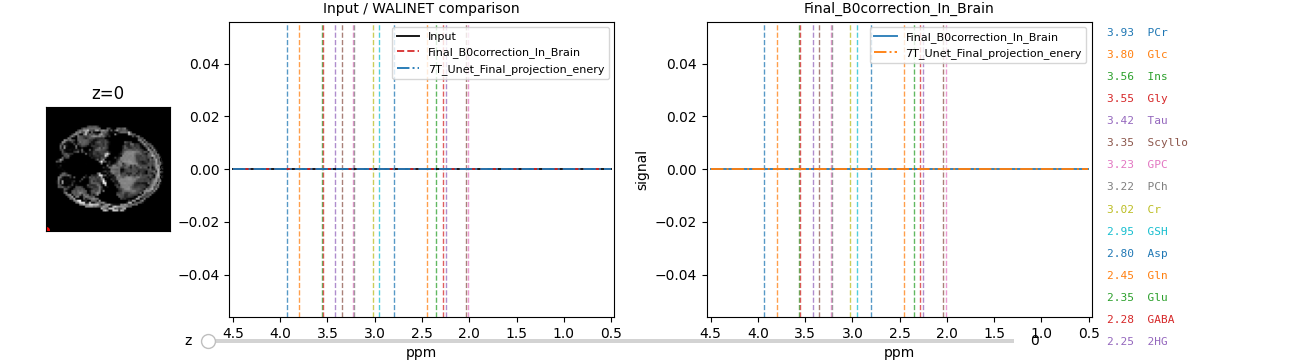

(<Figure size 1300x360 with 4 Axes>,
 <Axes: title={'center': 'z=0'}>,
 [<Axes: title={'center': 'Input / WALINET comparison'}, xlabel='ppm', ylabel='signal'>,
  <Axes: title={'center': 'Final_B0correction_In_Brain'}, xlabel='ppm', ylabel='signal'>],
 <matplotlib.widgets.Slider at 0x7fb5144bf550>)

In [8]:
Nuisance_model_1 = np.real(spectra - out_model_1)
Model_1 = np.real(out_model_1)

has_model_2 = (
    "model_2" in globals()
    and model_2 is not None
    and model_2 != ""
    and "out_model_2" in globals()
    and out_model_2 is not None
)

if has_model_2:
    Nuisance_model_2 = np.real(spectra - out_model_2)
    Model_2 = np.real(out_model_2)


def vol_real(vol):
    return lambda x, y, z: np.real(vol[x, y, z, :])


spectrum_funcs = [
    make_spec_func(BeforeWALINET),
    make_spec_func(Nuisance_model_1),
    make_spec_func(Model_1),
]

labels = [
    "Input / WALINET comparison",
    model_1,
]

overlay_labels = [
    "Input",
    model_1,
]

extra_spectrum_funcs = None
extra_labels = None

if has_model_2:
    extra_spectrum_funcs = [
        vol_real(Nuisance_model_2),
        vol_real(Model_2),
    ]

    extra_labels = [
        model_2,
        model_2,
    ]


interactive_spectra_viewer_multi(
    image_volume=T1,
    spectrum_funcs=spectrum_funcs,
    labels=labels,
    overlay_labels=overlay_labels,
    extra_spectrum_funcs=extra_spectrum_funcs,
    extra_labels=extra_labels,
    x_axis=ppm,
    x_label="ppm",
    ppm_min=0.5,
    ppm_max=4.5,
    compact=True,
    metabolite_lines=metabolite_lines,
)

# Validation set inference

In [9]:
res_1 = runNNOnTrainDataH5(
    device=device,
    exp=model_1,
    h5_path=f"../data/{Scanner}/{Vol}/TrainData/TrainData_{version}.h5",
    checkpoint="model_best.pt",
    return_all=True,
)

res_2 = None

if (
    "model_2" in globals()
    and model_2 is not None
    and model_2 != ""
):
    res_2 = runNNOnTrainDataH5(
        device=device,
        exp=model_2,
        h5_path=f"../data/{Scanner}/{Vol}/TrainData/TrainData_{version}.h5",
        checkpoint="model_best.pt",
        return_all=True,
    )

[runNNOnTrainDataH5] Experiment: Final_B0correction_In_Brain
[runNNOnTrainDataH5] Architecture: ynet
[runNNOnTrainDataH5] Normalization: projection_energy
[runNNOnTrainDataH5] H5: ../data/7T/B0corrected_wo_LipidMask/Vol5/TrainData/TrainData_v_1.0_final.h5
[runNNOnTrainDataH5] Loading checkpoint: ../models/Final_B0correction_In_Brain/model_best.pt
[runNNOnTrainDataH5] done in 8.9s
[runNNOnTrainDataH5] Experiment: 7T_Unet_Final_projection_enery
[runNNOnTrainDataH5] Architecture: unet
[runNNOnTrainDataH5] Normalization: projection_energy
[runNNOnTrainDataH5] H5: ../data/7T/B0corrected_wo_LipidMask/Vol5/TrainData/TrainData_v_1.0_final.h5
[runNNOnTrainDataH5] Loading checkpoint: ../models/7T_Unet_Final_projection_enery/model_best.pt
[runNNOnTrainDataH5] done in 11.1s


(<Figure size 1080x890 with 18 Axes>,
 array([[<Axes: title={'center': 'Input'}, ylabel='#4'>,
         <Axes: title={'center': 'Nuisance'}>,
         <Axes: title={'center': 'Metabos'}>],
        [<Axes: ylabel='#5'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='#6'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='#7'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='#8'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='ppm', ylabel='#9'>, <Axes: xlabel='ppm'>,
         <Axes: xlabel='ppm'>]], dtype=object))

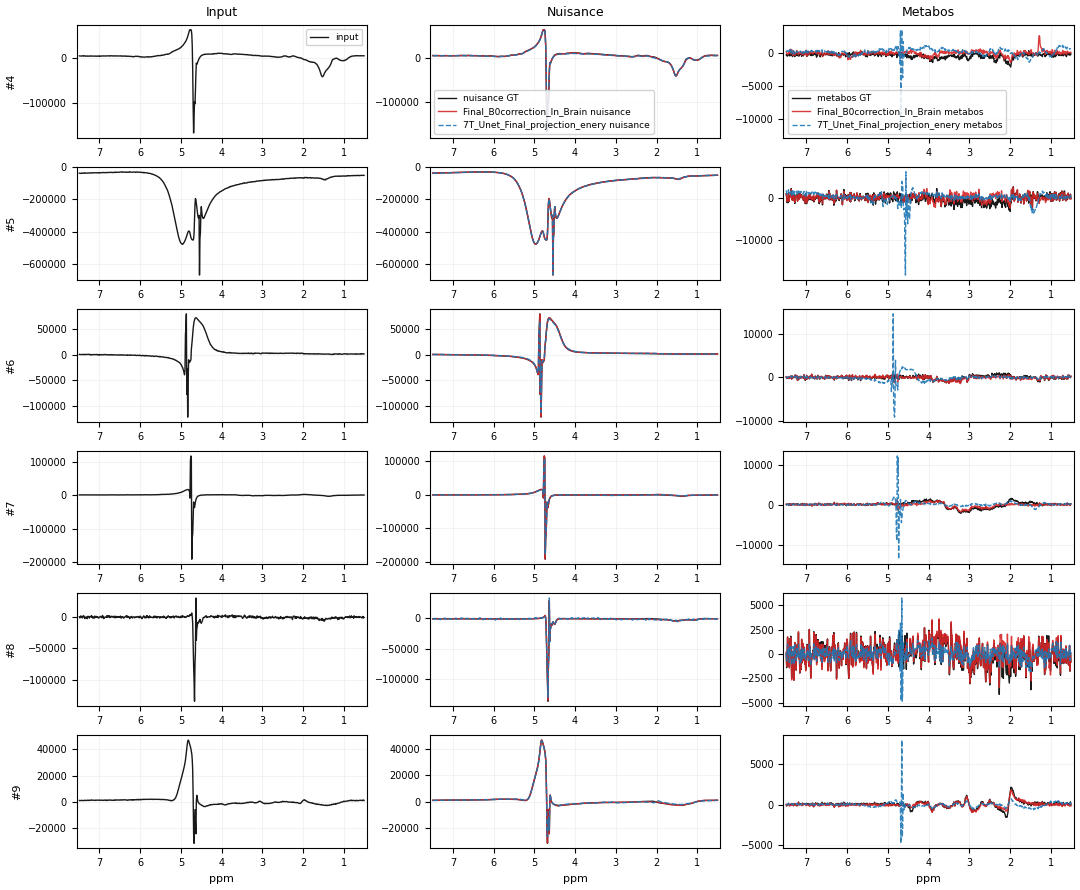

In [10]:
plot_train_inference_grid(
    res_1,
    res_extra=res_2,
    indices=range(4, 10),
    x_axis=ppm,
    x_label="ppm",
    ppm_min=0.5,
    ppm_max=7.5,
    label=model_1,
    extra_label=model_2 if res_2 is not None else "",
)

In [13]:
print(model_1, compute_normalized_nuisance_mse(res_1, res_1["normalization"]))
print(model_2, compute_normalized_nuisance_mse(res_2, res_2["normalization"]))

Final_B0correction_In_Brain 6.084290974746692e-05
7T_Unet_Final_projection_enery 0.00018614522056422235
